In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Loading the Dataset
import pyreadstat

df, meta = pyreadstat.read_sav('track_cycle.sav')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1665, 80)


In [3]:
# Previewing the Data
print("First 5 rows:")
df.head()

First 5 rows:


,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1.0,0.0,1.0,0.0,29.0,27.33,17.0,12.0,12.0,...,9.0,NaN,NaN,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nfp8122,3.0,0.0,1.0,0.0,29.0,NaN,15.0,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nfp8122,4.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nfp8122,5.0,0.0,1.0,0.0,28.0,NaN,16.0,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Checking all colomn names
print("\nColumns:")
print(df.columns.tolist())



Columns:
['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Schoolyears', 'SchoolyearsM', '

In [5]:
#Checking missing values in the dataset
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ClientID                   0
CycleNumber                0
Group                      0
CycleWithPeakorNot         0
ReproductiveCategory       0
                        ... 
NextpregM               1524
Spousesame              1523
SpousesameM             1523
Timeattemptpreg         1523
BMI                     1534
Length: 80, dtype: int64


In [6]:
# Analysing Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

                            Missing Count  Percentage
MensesScoreDay14                     1664        99.9
MensesScoreDay15                     1664        99.9
MensesScoreDay12                     1664        99.9
MensesScoreDay13                     1664        99.9
MensesScoreDay11                     1663        99.9
...                                   ...         ...
MensesScoreDayTwo                       4         0.2
TotalMensesScore                        4         0.2
NumberofDaysofIntercourse               1         0.1
TotalFertilityFormula                   2         0.1
IntercourseInFertileWindow              1         0.1

[70 rows x 2 columns]


In [7]:
#Categorizing missing values
print("Columns with >50% missing:")
print(missing_df[missing_df['Percentage'] > 50].index.tolist())

print("\nColumns with 5-50% missing:")
print(missing_df[(missing_df['Percentage'] >= 5) & (missing_df['Percentage'] <= 50)].index.tolist())

print("\nColumns with <5% missing:")
print(missing_df[missing_df['Percentage'] < 5].index.tolist())

Columns with >50% missing:
['MensesScoreDay14', 'MensesScoreDay15', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay11', 'MensesScoreDayTen', 'Wedding', 'MensesScoreDayNine', 'Prevmethod', 'Methoddate', 'Girls', 'Boys', 'MensesScoreDayEight', 'LivingkidsM', 'IntercourseDuringUnusBleed', 'PhasesBleeding', 'MeanBleedingIntensity', 'BMI', 'Yearsmarried', 'Weight', 'Height', 'SchoolyearsM', 'Schoolyears', 'Miscarriages', 'IncomeM', 'MedvitsM', 'Abortions', 'MeanCycleLength', 'Ethnicity', 'Religion', 'Numberpreg', 'Livingkids', 'Reprocate', 'Age', 'MeanMensesLength', 'MaristatusM', 'AgeM', 'Maristatus', 'Timeattemptpreg', 'Breastfeeding', 'Nextpreg', 'Whychart', 'NextpregM', 'ReligionM', 'EthnicityM', 'Medvits', 'Method', 'Spousesame', 'SpousesameM', 'OccupationM', 'MensesScoreDaySeven', 'MensesScoreDaySix']

Columns with 5-50% missing:
['MensesScoreDayFive', 'FirstDayofHigh', 'LengthofLutealPhase', 'EstimatedDayofOvulation', 'MensesScoreDayFour']

Columns with <5% missing:
['TotalDa

In [8]:
# Dropping columns with >50% missing
cols_to_drop = missing_df[missing_df['Percentage'] > 50].index.tolist()
df = df.drop(columns=cols_to_drop)
print("Shape after dropping high-missing columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping high-missing columns: (1665, 28)
Remaining columns: ['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries']


In [9]:
# Filling remaining missing values with median
cols_to_fill = df.columns[df.isnull().any()].tolist()
print("Columns with remaining missing values:", cols_to_fill)

for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after filling:")
print(df.isnull().sum().sum(), "missing values remaining")

Columns with remaining missing values: ['EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding']

Missing values after filling:
0 missing values remaining


In [10]:
# Checking and removing duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 13
Shape after removing duplicates: (1652, 28)


In [11]:
#Checking for outliers in key columns
key_cols = ['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'LengthofMenses']

for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (lower={lower:.1f}, upper={upper:.1f})")

LengthofCycle: 73 outliers (lower=21.0, upper=37.0)
EstimatedDayofOvulation: 44 outliers (lower=8.0, upper=24.0)
LengthofLutealPhase: 97 outliers (lower=9.0, upper=17.0)
LengthofMenses: 6 outliers (lower=1.0, upper=9.0)


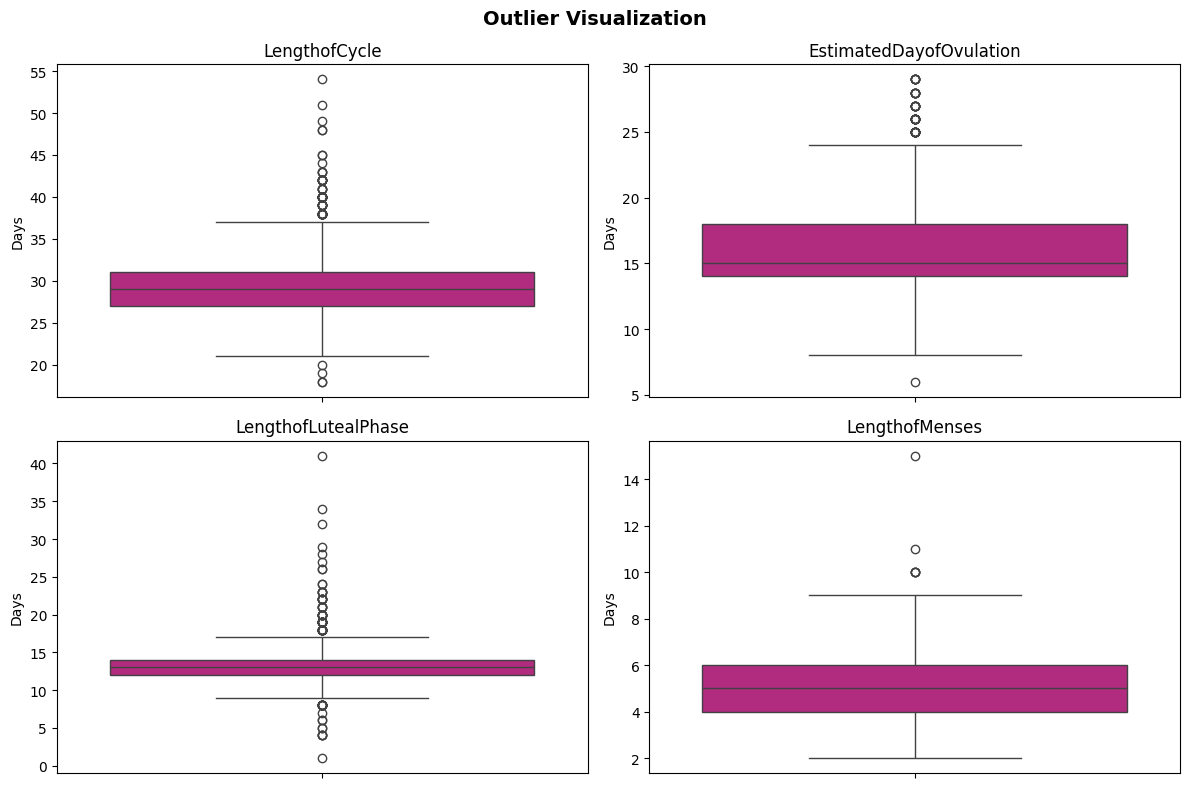

In [12]:
# Visualizing the outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

key_cols = ['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'LengthofMenses']

for ax, col in zip(axes.flatten(), key_cols):
    sns.boxplot(y=df[col], ax=ax, color='mediumvioletred')
    ax.set_title(col)
    ax.set_ylabel('Days')

plt.suptitle('Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Removing unrealistic outliers
before = df.shape[0]

# Removing unrealistic menses length
df = df[df['LengthofMenses'] <= 9]

# Removing unrealistic luteal phase
df = df[df['LengthofLutealPhase'] >= 2]

after = df.shape[0]
print(f"Rows removed: {before - after}")
print(f"Shape after removing outliers: {df.shape}")

Rows removed: 7
Shape after removing outliers: (1645, 28)


In [14]:
# Checking data types
print("Data Types:")
print(df.dtypes)

Data Types:
ClientID                       object
CycleNumber                   float64
Group                         float64
CycleWithPeakorNot            float64
ReproductiveCategory          float64
LengthofCycle                 float64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
MensesScoreDayFive            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
Medvitexplain                  object
Gynosurgeries                  object


In [15]:
# Inspecting object columns
obj_cols = ['Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries']
for col in obj_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())


Medvitexplain unique values:
Medvitexplain
                                                                                 1544
Multivitamin                                                                       18
Prenatal vitamin                                                                    4
Vitamin                                                                             2
prenatal vitamins                                                                   2
                                                                                 ... 
Iron supplement and progesterone from peak day plus 3 to the end of the cycle       1
daily vitamin                                                                       1
multi vitamin                                                                       1
benzaclin - acne topical treatment                                                  1
Multi-Vitamin                                                                       1
Name: coun

In [16]:
# Dropping irrelevant text columns
df = df.drop(columns=['Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries'])
print("Shape after dropping text columns:", df.shape)

Shape after dropping text columns: (1645, 24)


In [17]:
#Final cleaning check
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Shape: (1645, 24)

Missing values: 0

Duplicates: 0

Data types:
ClientID                       object
CycleNumber                   float64
Group                         float64
CycleWithPeakorNot            float64
ReproductiveCategory          float64
LengthofCycle                 float64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
MensesScoreDayFive            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
dtype: object


In [18]:
#Saving cleaned dataset 
df.to_csv('cycle_data_cleaned.csv', index=False)
print("Cleaned dataset saved as cycle_data_cleaned.csv")
print("Shape:", df.shape)

Cleaned dataset saved as cycle_data_cleaned.csv
Shape: (1645, 24)


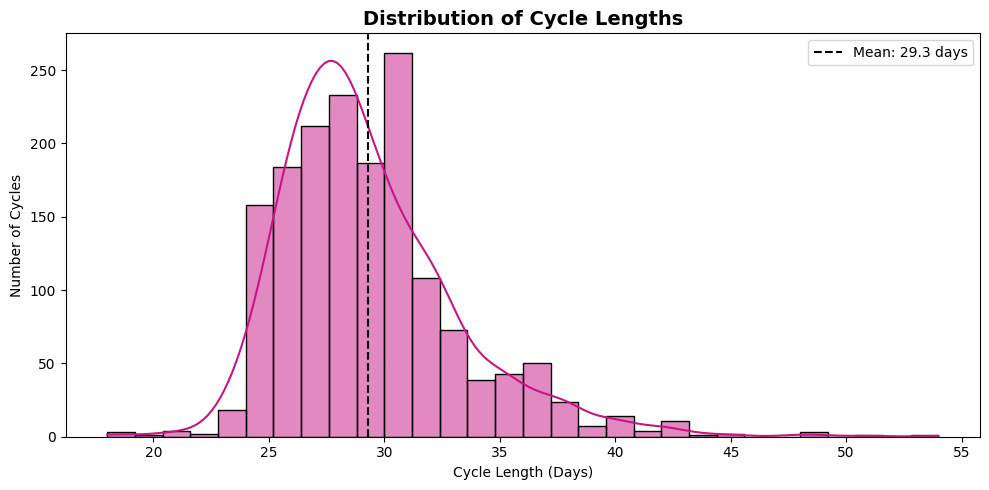

In [19]:
# Distribution of Cycle Lengths(Our key target variable)
plt.figure(figsize=(10, 5))
sns.histplot(df['LengthofCycle'], bins=30, kde=True, color='mediumvioletred')
plt.title('Distribution of Cycle Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Cycle Length (Days)')
plt.ylabel('Number of Cycles')
plt.axvline(df['LengthofCycle'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofCycle"].mean():.1f} days')
plt.legend()
plt.tight_layout()
plt.show()

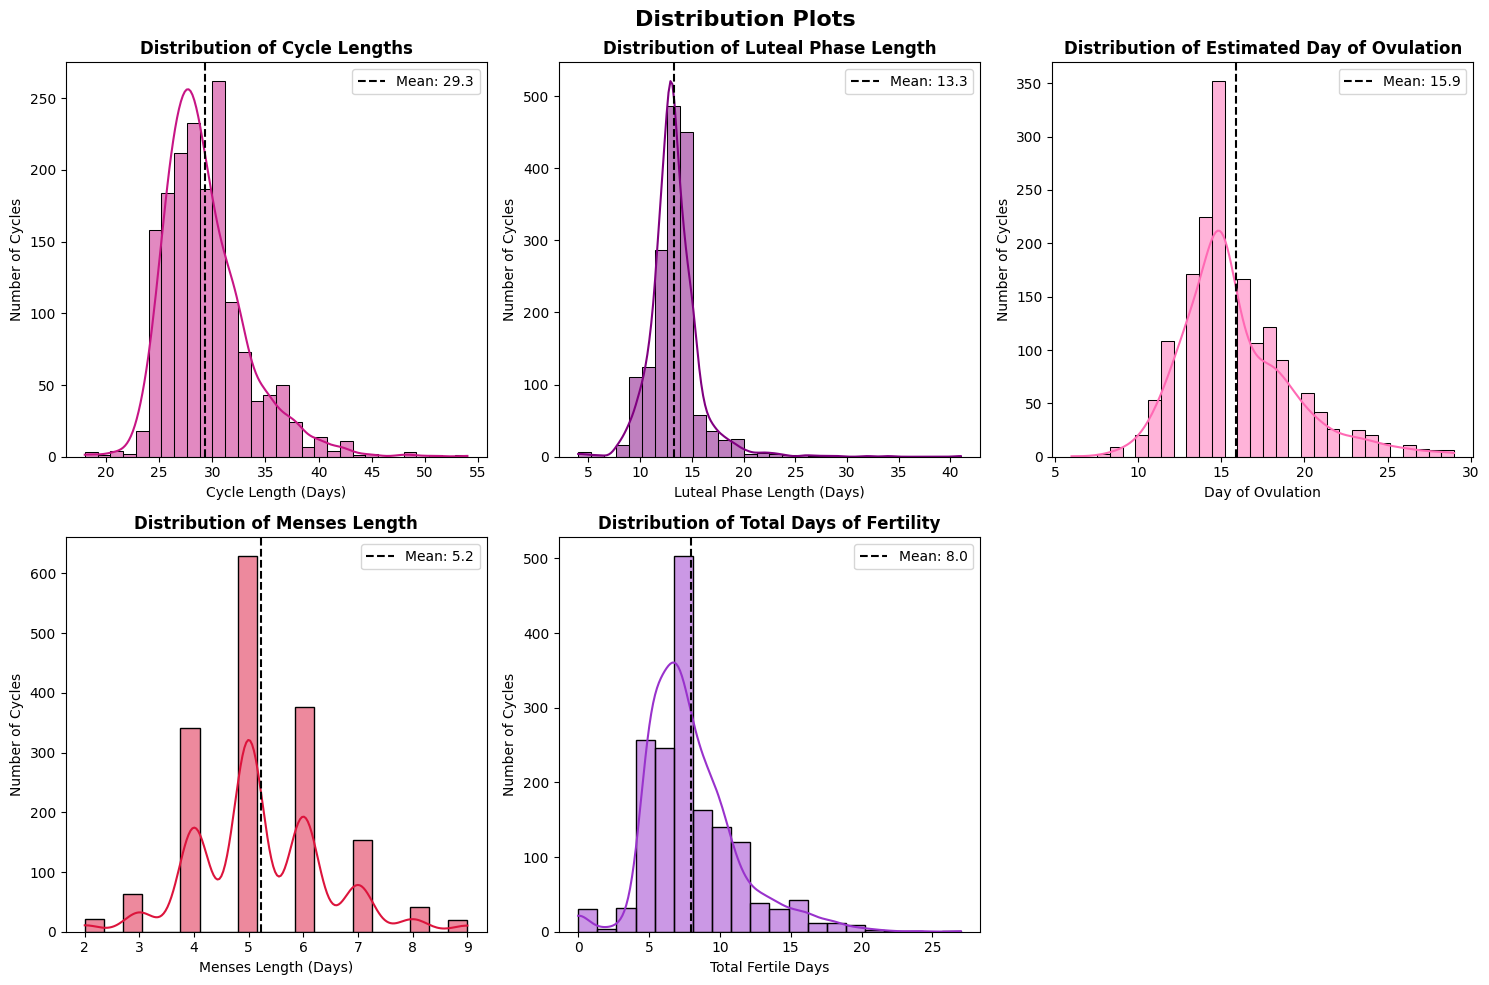

In [20]:
# DISTRIBUTION PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length
sns.histplot(df['LengthofCycle'], bins=30, kde=True, color='mediumvioletred', ax=axes[0,0])
axes[0,0].set_title('Distribution of Cycle Lengths', fontweight='bold')
axes[0,0].set_xlabel('Cycle Length (Days)')
axes[0,0].set_ylabel('Number of Cycles')
axes[0,0].axvline(df['LengthofCycle'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofCycle"].mean():.1f}')
axes[0,0].legend()

# Luteal Phase
sns.histplot(df['LengthofLutealPhase'], bins=30, kde=True, color='purple', ax=axes[0,1])
axes[0,1].set_title('Distribution of Luteal Phase Length', fontweight='bold')
axes[0,1].set_xlabel('Luteal Phase Length (Days)')
axes[0,1].set_ylabel('Number of Cycles')
axes[0,1].axvline(df['LengthofLutealPhase'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofLutealPhase"].mean():.1f}')
axes[0,1].legend()

# Ovulation Day
sns.histplot(df['EstimatedDayofOvulation'], bins=30, kde=True, color='hotpink', ax=axes[0,2])
axes[0,2].set_title('Distribution of Estimated Day of Ovulation', fontweight='bold')
axes[0,2].set_xlabel('Day of Ovulation')
axes[0,2].set_ylabel('Number of Cycles')
axes[0,2].axvline(df['EstimatedDayofOvulation'].mean(), color='black', linestyle='--', label=f'Mean: {df["EstimatedDayofOvulation"].mean():.1f}')
axes[0,2].legend()

# Menses Length
sns.histplot(df['LengthofMenses'], bins=20, kde=True, color='crimson', ax=axes[1,0])
axes[1,0].set_title('Distribution of Menses Length', fontweight='bold')
axes[1,0].set_xlabel('Menses Length (Days)')
axes[1,0].set_ylabel('Number of Cycles')
axes[1,0].axvline(df['LengthofMenses'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofMenses"].mean():.1f}')
axes[1,0].legend()

# Total Days of Fertility
sns.histplot(df['TotalDaysofFertility'], bins=20, kde=True, color='darkorchid', ax=axes[1,1])
axes[1,1].set_title('Distribution of Total Days of Fertility', fontweight='bold')
axes[1,1].set_xlabel('Total Fertile Days')
axes[1,1].set_ylabel('Number of Cycles')
axes[1,1].axvline(df['TotalDaysofFertility'].mean(), color='black', linestyle='--', label=f'Mean: {df["TotalDaysofFertility"].mean():.1f}')
axes[1,1].legend()

# Hide empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Distribution Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

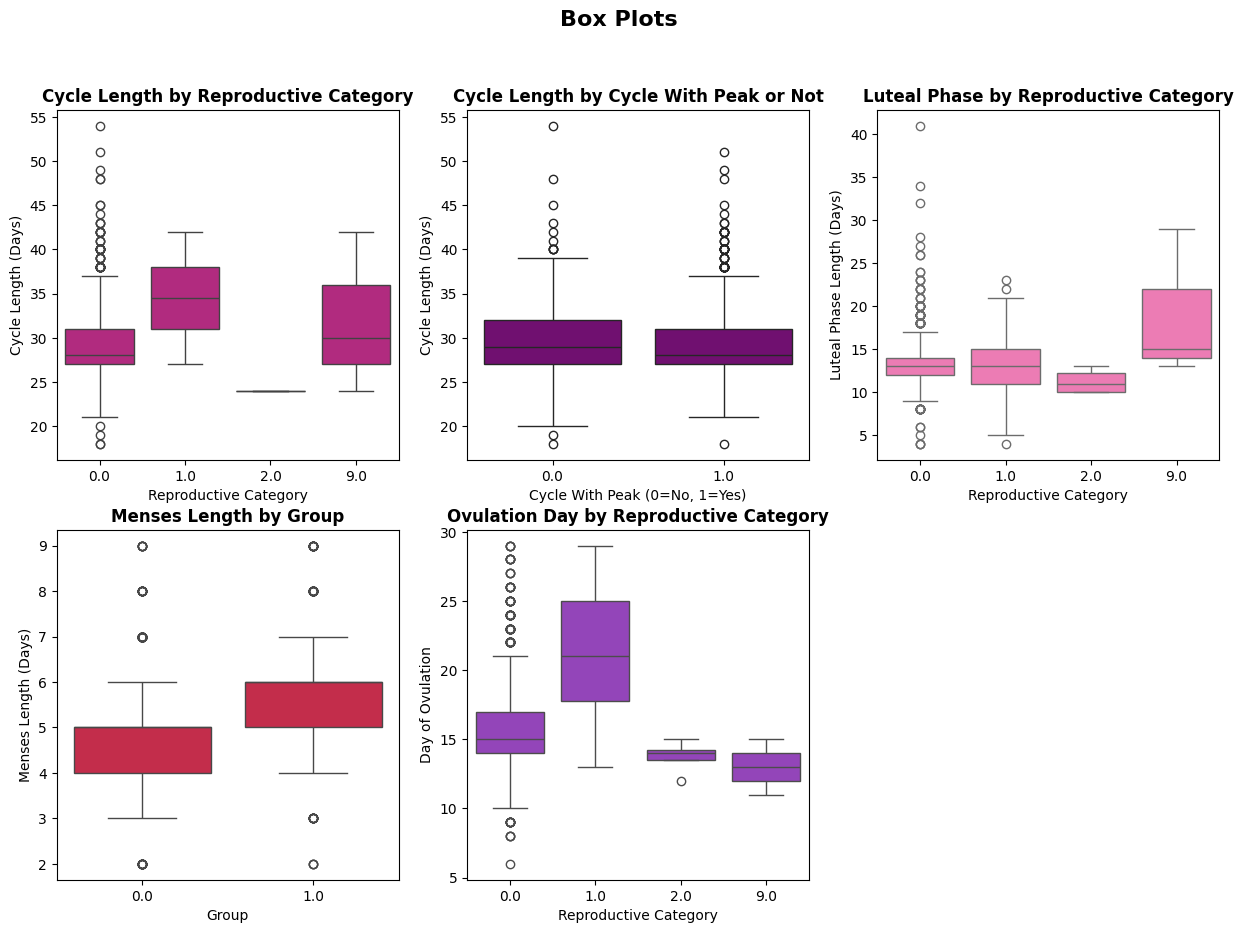

In [21]:
#BOX PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='LengthofCycle', data=df, color='mediumvioletred', ax=axes[0,0])
axes[0,0].set_title('Cycle Length by Reproductive Category', fontweight='bold')
axes[0,0].set_xlabel('Reproductive Category')
axes[0,0].set_ylabel('Cycle Length (Days)')

# Cycle Length by CycleWithPeakorNot
sns.boxplot(x='CycleWithPeakorNot', y='LengthofCycle', data=df, color='purple', ax=axes[0,1])
axes[0,1].set_title('Cycle Length by Cycle With Peak or Not', fontweight='bold')
axes[0,1].set_xlabel('Cycle With Peak (0=No, 1=Yes)')
axes[0,1].set_ylabel('Cycle Length (Days)')

# Luteal Phase by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='LengthofLutealPhase', data=df, color='hotpink', ax=axes[0,2])
axes[0,2].set_title('Luteal Phase by Reproductive Category', fontweight='bold')
axes[0,2].set_xlabel('Reproductive Category')
axes[0,2].set_ylabel('Luteal Phase Length (Days)')

# Menses Length by Group
sns.boxplot(x='Group', y='LengthofMenses', data=df, color='crimson', ax=axes[1,0])
axes[1,0].set_title('Menses Length by Group', fontweight='bold')
axes[1,0].set_xlabel('Group')
axes[1,0].set_ylabel('Menses Length (Days)')

# Ovulation Day by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='EstimatedDayofOvulation', data=df, color='darkorchid', ax=axes[1,1])
axes[1,1].set_title('Ovulation Day by Reproductive Category', fontweight='bold')
axes[1,1].set_xlabel('Reproductive Category')
axes[1,1].set_ylabel('Day of Ovulation')

# Hidng empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout

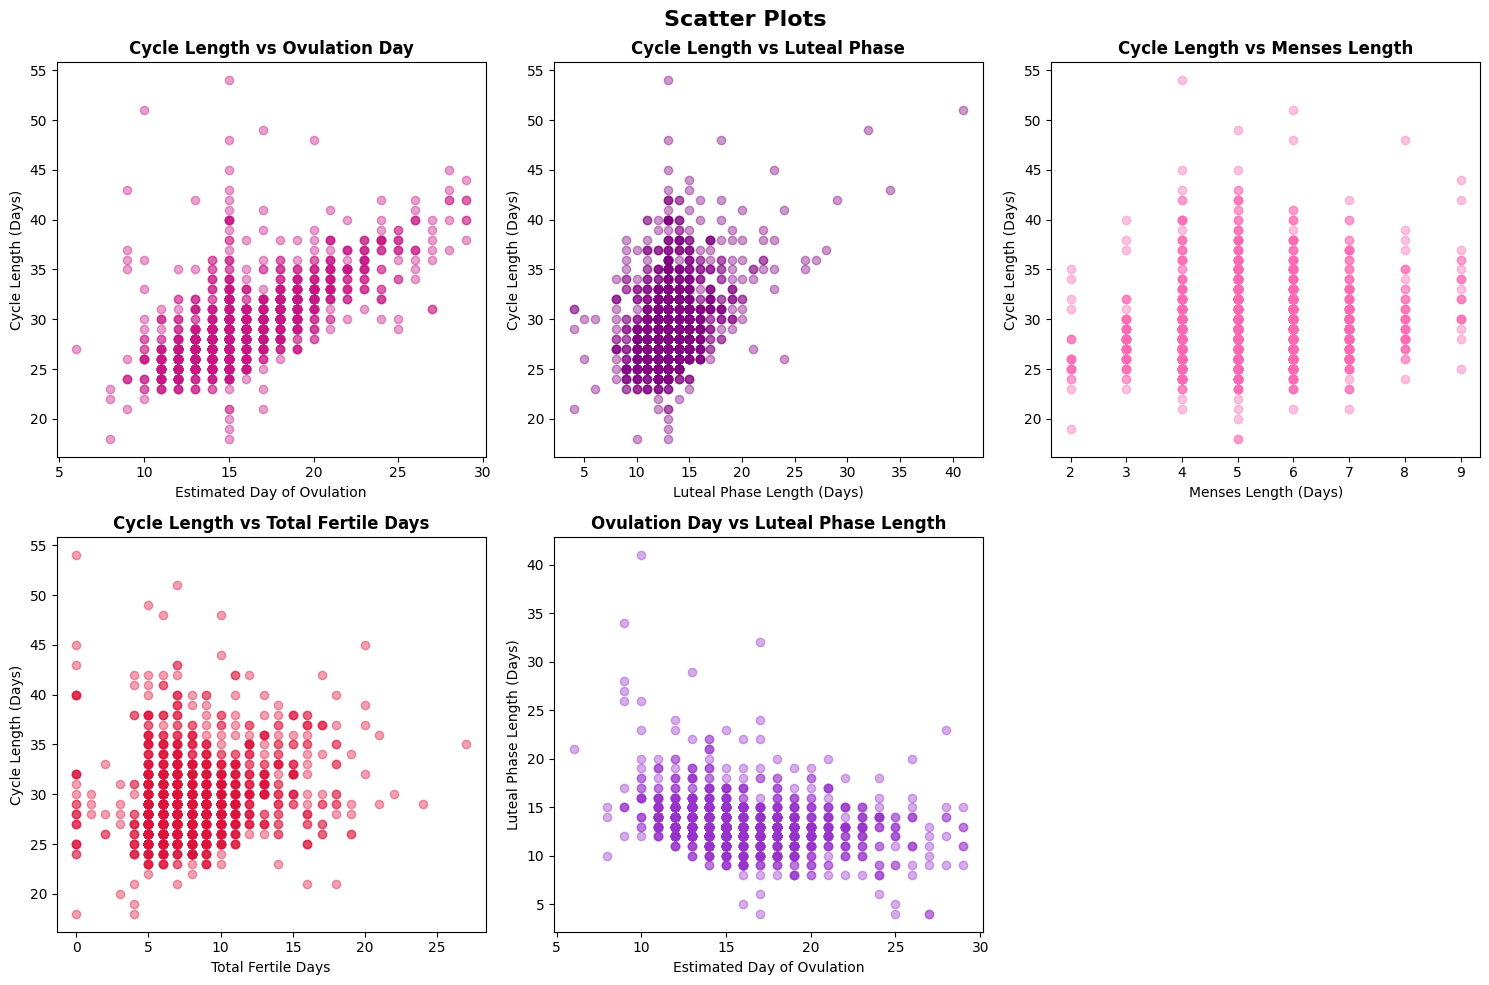

In [22]:
# SCATTER PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length vs Ovulation Day
axes[0,0].scatter(df['EstimatedDayofOvulation'], df['LengthofCycle'], color='mediumvioletred', alpha=0.4)
axes[0,0].set_title('Cycle Length vs Ovulation Day', fontweight='bold')
axes[0,0].set_xlabel('Estimated Day of Ovulation')
axes[0,0].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Luteal Phase
axes[0,1].scatter(df['LengthofLutealPhase'], df['LengthofCycle'], color='purple', alpha=0.4)
axes[0,1].set_title('Cycle Length vs Luteal Phase', fontweight='bold')
axes[0,1].set_xlabel('Luteal Phase Length (Days)')
axes[0,1].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Menses Length
axes[0,2].scatter(df['LengthofMenses'], df['LengthofCycle'], color='hotpink', alpha=0.4)
axes[0,2].set_title('Cycle Length vs Menses Length', fontweight='bold')
axes[0,2].set_xlabel('Menses Length (Days)')
axes[0,2].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Total Fertile Days
axes[1,0].scatter(df['TotalDaysofFertility'], df['LengthofCycle'], color='crimson', alpha=0.4)
axes[1,0].set_title('Cycle Length vs Total Fertile Days', fontweight='bold')
axes[1,0].set_xlabel('Total Fertile Days')
axes[1,0].set_ylabel('Cycle Length (Days)')

# Ovulation Day vs Luteal Phase
axes[1,1].scatter(df['EstimatedDayofOvulation'], df['LengthofLutealPhase'], color='darkorchid', alpha=0.4)
axes[1,1].set_title('Ovulation Day vs Luteal Phase Length', fontweight='bold')
axes[1,1].set_xlabel('Estimated Day of Ovulation')
axes[1,1].set_ylabel('Luteal Phase Length (Days)')

# Hide empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Scatter Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

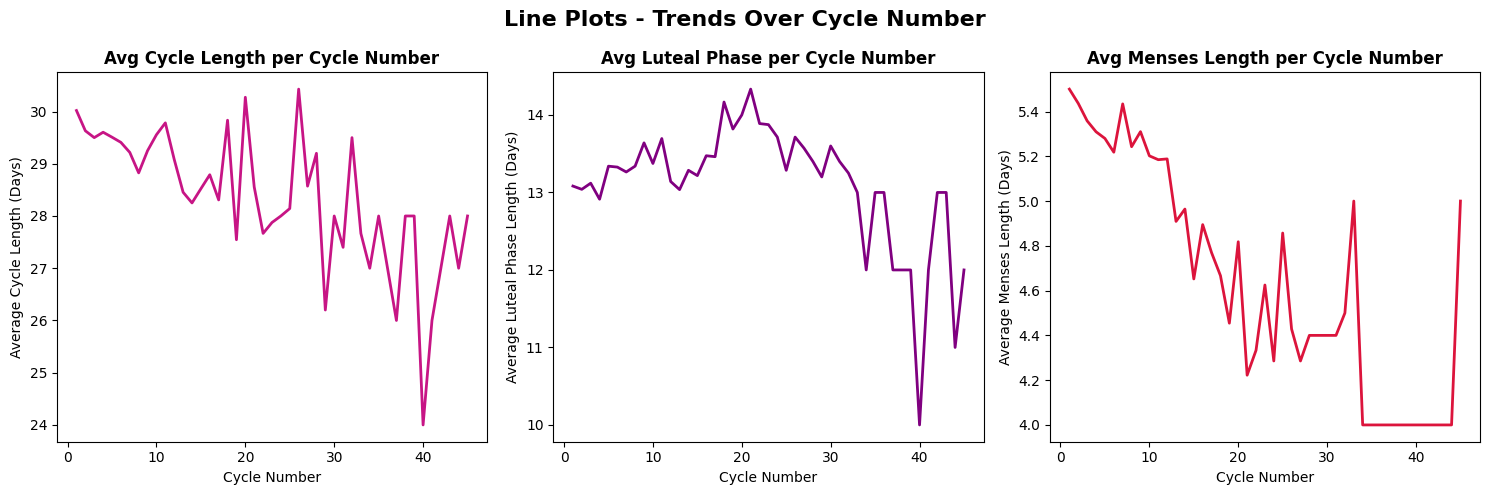

In [23]:
#LINE PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Average Cycle Length per Cycle Number
cycle_avg = df.groupby('CycleNumber')['LengthofCycle'].mean()
axes[0].plot(cycle_avg.index, cycle_avg.values, color='mediumvioletred', linewidth=2)
axes[0].set_title('Avg Cycle Length per Cycle Number', fontweight='bold')
axes[0].set_xlabel('Cycle Number')
axes[0].set_ylabel('Average Cycle Length (Days)')

# Average Luteal Phase per Cycle Number
luteal_avg = df.groupby('CycleNumber')['LengthofLutealPhase'].mean()
axes[1].plot(luteal_avg.index, luteal_avg.values, color='purple', linewidth=2)
axes[1].set_title('Avg Luteal Phase per Cycle Number', fontweight='bold')
axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('Average Luteal Phase Length (Days)')

# Average Menses Length per Cycle Number
menses_avg = df.groupby('CycleNumber')['LengthofMenses'].mean()
axes[2].plot(menses_avg.index, menses_avg.values, color='crimson', linewidth=2)
axes[2].set_title('Avg Menses Length per Cycle Number', fontweight='bold')
axes[2].set_xlabel('Cycle Number')
axes[2].set_ylabel('Average Menses Length (Days)')

plt.suptitle('Line Plots - Trends Over Cycle Number', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

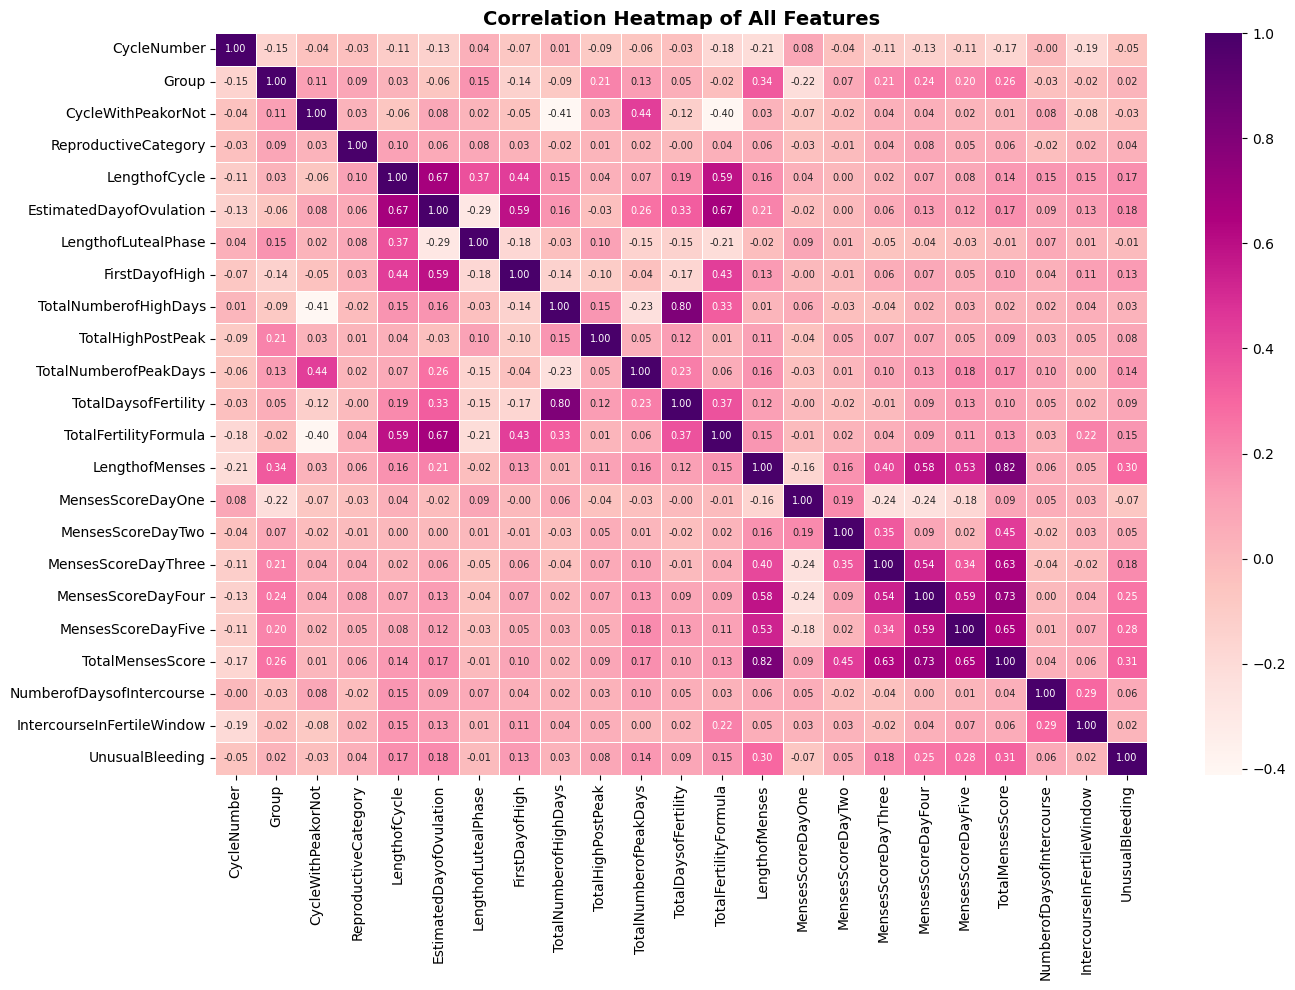

In [24]:
#CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['ClientID']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

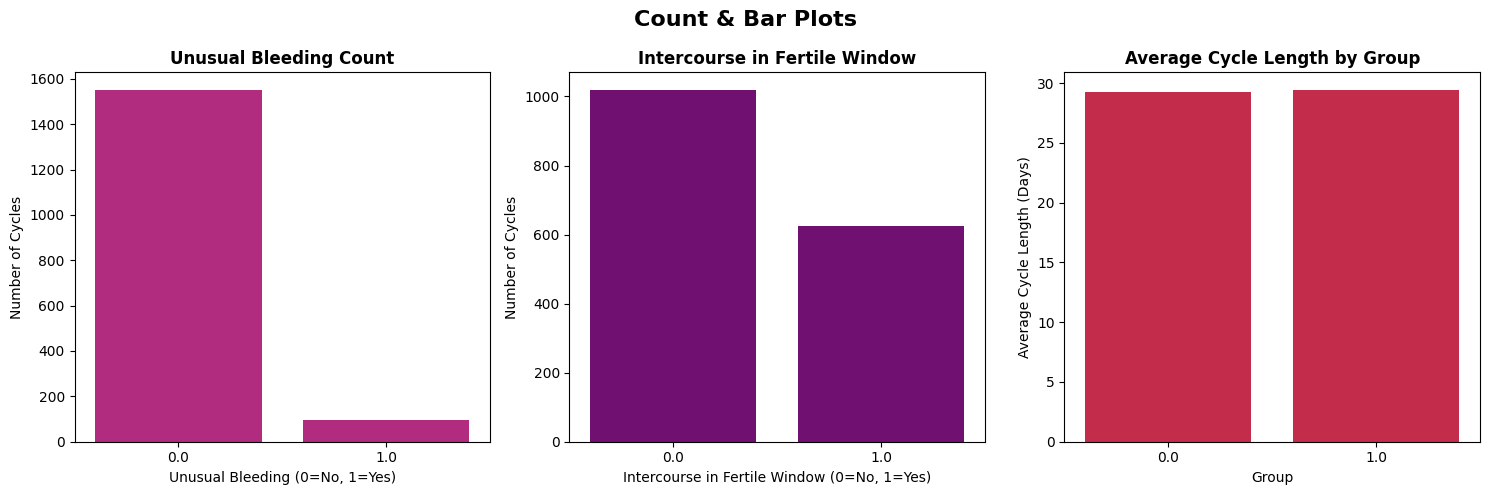

In [25]:
# COUNT & BAR PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Unusual Bleeding Count
sns.countplot(x='UnusualBleeding', data=df, color='mediumvioletred', ax=axes[0])
axes[0].set_title('Unusual Bleeding Count', fontweight='bold')
axes[0].set_xlabel('Unusual Bleeding (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Cycles')

# Intercourse in Fertile Window Count
sns.countplot(x='IntercourseInFertileWindow', data=df, color='purple', ax=axes[1])
axes[1].set_title('Intercourse in Fertile Window', fontweight='bold')
axes[1].set_xlabel('Intercourse in Fertile Window (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Cycles')

# Average Cycle Length by Group
group_avg = df.groupby('Group')['LengthofCycle'].mean().reset_index()
sns.barplot(x='Group', y='LengthofCycle', data=group_avg, color='crimson', ax=axes[2])
axes[2].set_title('Average Cycle Length by Group', fontweight='bold')
axes[2].set_xlabel('Group')
axes[2].set_ylabel('Average Cycle Length (Days)')

plt.suptitle('Count & Bar Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

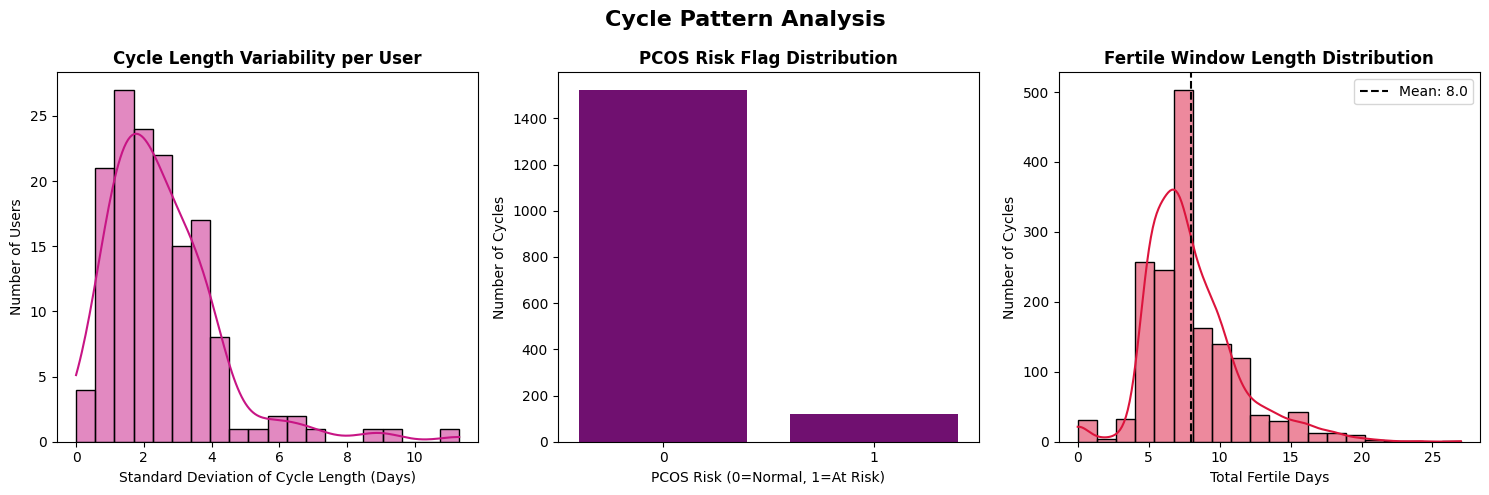

In [26]:
# Cycle Pattern Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cycle Length Variability per User
cycle_std = df.groupby('ClientID')['LengthofCycle'].std().dropna()
sns.histplot(cycle_std, bins=20, kde=True, color='mediumvioletred', ax=axes[0])
axes[0].set_title('Cycle Length Variability per User', fontweight='bold')
axes[0].set_xlabel('Standard Deviation of Cycle Length (Days)')
axes[0].set_ylabel('Number of Users')

# PCOS Risk Flag Distribution
df['PCOS_Risk'] = df['LengthofCycle'].apply(lambda x: 1 if x < 21 or x > 35 else 0)
sns.countplot(x='PCOS_Risk', data=df, color='purple', ax=axes[1])
axes[1].set_title('PCOS Risk Flag Distribution', fontweight='bold')
axes[1].set_xlabel('PCOS Risk (0=Normal, 1=At Risk)')
axes[1].set_ylabel('Number of Cycles')

# Fertile Window Length Distribution
sns.histplot(df['TotalDaysofFertility'], bins=20, kde=True, color='crimson', ax=axes[2])
axes[2].set_title('Fertile Window Length Distribution', fontweight='bold')
axes[2].set_xlabel('Total Fertile Days')
axes[2].set_ylabel('Number of Cycles')
axes[2].axvline(df['TotalDaysofFertility'].mean(), color='black', linestyle='--', label=f'Mean: {df["TotalDaysofFertility"].mean():.1f}')
axes[2].legend()

plt.suptitle('Cycle Pattern Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Feature Engineering
# Sort by user and cycle number first
df = df.sort_values(['ClientID', 'CycleNumber']).reset_index(drop=True)

# Previous cycle lengths
df['PrevCycleLength'] = df.groupby('ClientID')['LengthofCycle'].shift(1)
df['Prev2CycleLength'] = df.groupby('ClientID')['LengthofCycle'].shift(2)
df['Prev3CycleLength'] = df.groupby('ClientID')['LengthofCycle'].shift(3)

# Rolling average of last 3 cycles
df['RollingAvg3'] = df.groupby('ClientID')['LengthofCycle'].transform(lambda x: x.shift(1).rolling(3).mean())

# Cycle variability - std of last 3 cycles
df['CycleVariability'] = df.groupby('ClientID')['LengthofCycle'].transform(lambda x: x.shift(1).rolling(3).std())

# Is irregular flag
df['IsIrregular'] = df['LengthofCycle'].apply(lambda x: 1 if x < 21 or x > 35 else 0)

print("New features added!")
print("Shape:", df.shape)
print("\nNew columns:")
print(df[['ClientID', 'CycleNumber', 'LengthofCycle', 'PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability', 'IsIrregular']].head(10))

New features added!
Shape: (1645, 31)

New columns:
  ClientID  CycleNumber  LengthofCycle  PrevCycleLength  Prev2CycleLength  \
0  nfp8020          1.0           27.0              NaN               NaN   
1  nfp8020          2.0           31.0             27.0               NaN   
2  nfp8020          3.0           27.0             31.0              27.0   
3  nfp8020          4.0           28.0             27.0              31.0   
4  nfp8020          5.0           27.0             28.0              27.0   
5  nfp8020          6.0           27.0             27.0              28.0   
6  nfp8020          7.0           27.0             27.0              27.0   
7  nfp8020          8.0           25.0             27.0              27.0   
8  nfp8020          9.0           24.0             25.0              27.0   
9  nfp8020         10.0           18.0             24.0              25.0   

   Prev3CycleLength  RollingAvg3  CycleVariability  IsIrregular  
0               NaN          NaN  

In [28]:
# Dropping NaN rows created by feature engineering
before = df.shape[0]
df = df.dropna(subset=['PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability'])
after = df.shape[0]

print(f"Rows removed: {before - after}")
print(f"Shape after dropping NaN rows: {df.shape}")

Rows removed: 442
Shape after dropping NaN rows: (1203, 31)


In [29]:
# Feature Selection
feature_cols = [
    'PrevCycleLength',
    'Prev2CycleLength', 
    'Prev3CycleLength',
    'RollingAvg3',
    'CycleVariability',
    'EstimatedDayofOvulation',
    'LengthofLutealPhase',
    'FirstDayofHigh',
    'TotalFertilityFormula',
    'LengthofMenses',
    'IsIrregular',
    'PCOS_Risk'
]

target = 'LengthofCycle'

print("Features selected:", len(feature_cols))
print("Feature columns:", feature_cols)
print("\nTarget:", target)
print("\nFinal dataset shape:", df[feature_cols + [target]].shape)

Features selected: 12
Feature columns: ['PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalFertilityFormula', 'LengthofMenses', 'IsIrregular', 'PCOS_Risk']

Target: LengthofCycle

Final dataset shape: (1203, 13)


In [30]:
#Scale Features
from sklearn.preprocessing import StandardScaler

X = df[feature_cols]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("Features scaled successfully!")
print("\nBefore scaling - PrevCycleLength stats:")
print(X['PrevCycleLength'].describe())
print("\nAfter scaling - PrevCycleLength stats:")
print(X_scaled['PrevCycleLength'].describe())

Features scaled successfully!

Before scaling - PrevCycleLength stats:
count    1203.000000
mean       29.178720
std         3.872401
min        18.000000
25%        27.000000
50%        28.000000
75%        31.000000
max        51.000000
Name: PrevCycleLength, dtype: float64

After scaling - PrevCycleLength stats:
count    1.203000e+03
mean    -4.193561e-16
std      1.000416e+00
min     -2.887968e+00
25%     -5.628617e-01
50%     -3.045165e-01
75%      4.705189e-01
max      5.637422e+00
Name: PrevCycleLength, dtype: float64


In [31]:
# Saving cleaned and engineered dataset
df.to_csv('cycle_data_clean.csv', index=False)
print("Dataset saved as cycle_data_clean.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset saved as cycle_data_clean.csv
Shape: (1203, 31)
Columns: ['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PCOS_Risk', 'PrevCycleLength', 'Prev2CycleLength', 'Prev3CycleLength', 'RollingAvg3', 'CycleVariability', 'IsIrregular']


In [74]:
# PATIENT-HELD-OUT TRAIN/TEST SPLIT
# All cycles from the same woman stay together in either
# train or test - prevents transductive subject leakage

import numpy as np, os
os.makedirs('visuals', exist_ok=True)

unique_clients = df['ClientID'].unique()
np.random.seed(42)
np.random.shuffle(unique_clients)

split_idx     = int(len(unique_clients) * 0.8)
train_clients = unique_clients[:split_idx]
test_clients  = unique_clients[split_idx:]

train_df = df[df['ClientID'].isin(train_clients)]
test_df  = df[df['ClientID'].isin(test_clients)]

X_train = train_df[feature_cols].reset_index(drop=True)
X_test  = test_df[feature_cols].reset_index(drop=True)
y_train = train_df['LengthofCycle'].reset_index(drop=True)
y_test  = test_df['LengthofCycle'].reset_index(drop=True)
y_train_pcos = train_df['PCOS_Risk'].reset_index(drop=True)
y_test_pcos  = test_df['PCOS_Risk'].reset_index(drop=True)

print(f"Train patients: {len(train_clients)} | Train cycles: {len(X_train)}")
print(f"Test  patients: {len(test_clients)}  | Test  cycles: {len(X_test)}")
print(f"PCOS cases in test: {y_test_pcos.sum()} ({y_test_pcos.mean()*100:.1f}%)")

# Scaler fitted on train only — no data leakage into test set
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)
print("\nScaler fitted on training set only.")

Train patients: 100 | Train cycles: 961
Test  patients: 26  | Test  cycles: 242
PCOS cases in test: 8 (3.3%)

Scaler fitted on training set only.


In [75]:
# LINEAR REGRESSION 
# Training & Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print(f"Linear Regression")
print(f"MAE={lr_mae:.3f}")
print(f"RMSE={lr_rmse:.3f}")
print(f"R²={lr_r2:.3f}")

Linear Regression
MAE=0.513
RMSE=0.964
R²=0.914


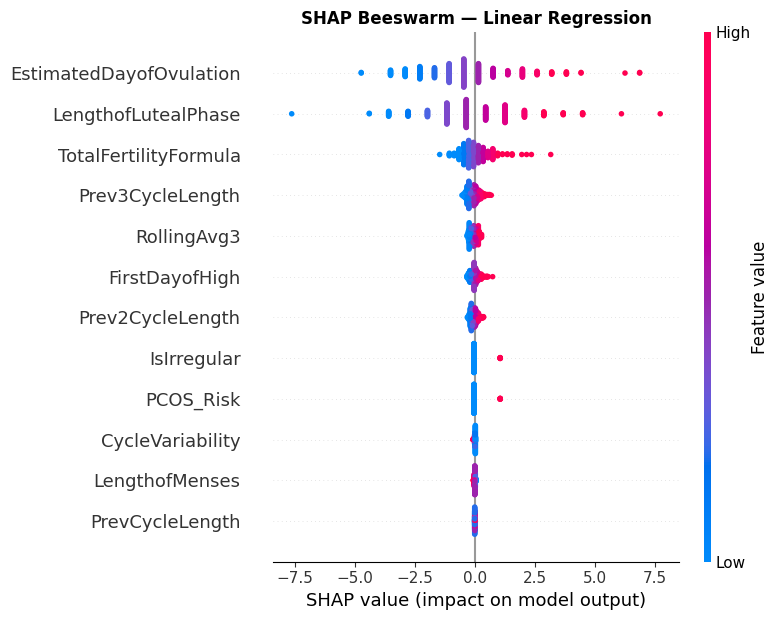

In [ ]:
# LINEAR REGRESSION 
# XAI: SHAP LinearExplainer -chosen since its exact and fast for linear models,
# computes Shapley values directly from coefficients

import shap, matplotlib.pyplot as plt

lr_explainer   = shap.LinearExplainer(lr_model, X_train)
lr_shap_values = lr_explainer.shap_values(X_test)
lr_explanation = shap.Explanation(
    values=lr_shap_values,
    base_values=lr_explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

shap.plots.beeswarm(lr_explanation, max_display=12, show=False)
plt.title("SHAP Beeswarm — Linear Regression", fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/xai_lr_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# RIDGE REGRESSION
# Training & Evaluation

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred  = ridge_model.predict(X_test)

ridge_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2   = r2_score(y_test, ridge_pred)

print(f"Ridge Regression")
print(f"MAE={ridge_mae:.3f}")
print(f"RMSE={ridge_rmse:.3f}")
print(f"R²={ridge_r2:.3f}")

Ridge Regression
MAE=0.515
RMSE=0.965
R²=0.914


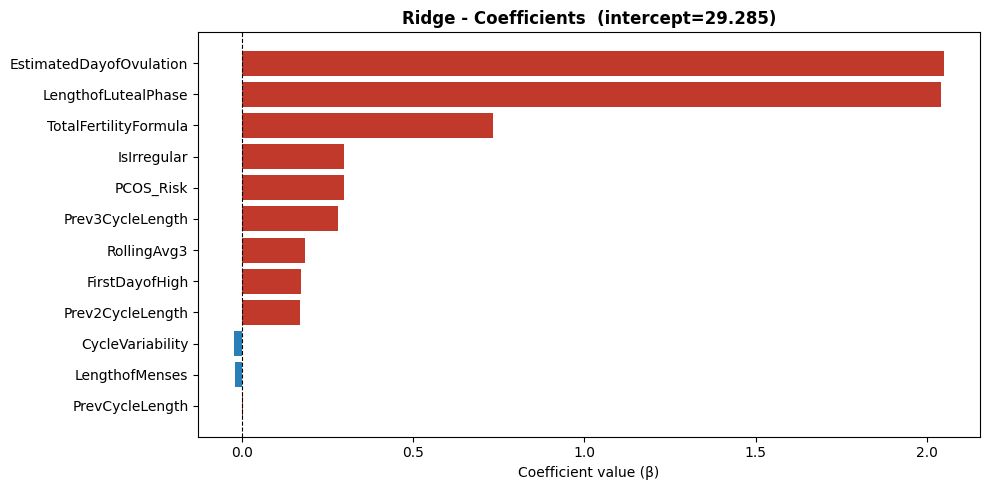

In [ ]:
# RIDGE REGRESSION 
# XAI: Coefficients bar chart
# Ridge shrinks but never zeros coefficients;
# bar chart shows exactly which features are suppressed

coef_df = pd.DataFrame({
    'Feature':     feature_cols,
    'Coefficient': ridge_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

colors = ['#c0392b' if c > 0 else '#2980b9' for c in coef_df['Coefficient']]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient value (β)')
ax.set_title(f'Ridge - Coefficients  (intercept={ridge_model.intercept_:.3f})', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/xai_ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# MODEL 3: LASSO REGRESSION 
# Training & Evaluation

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=5000)
lasso_model.fit(X_train, y_train)
lasso_pred  = lasso_model.predict(X_test)

lasso_mae  = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2   = r2_score(y_test, lasso_pred)

lasso_coef_df = pd.DataFrame({
    'Feature':     feature_cols,
    'Coefficient': lasso_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

zeroed = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]['Feature'].tolist()
print(f"Lasso")
print(f"MAE={lasso_mae:.3f}")
print(f"RMSE={lasso_rmse:.3f}")
print(f"R²={lasso_r2:.3f}")
print(f"Features zeroed ({len(zeroed)}): {zeroed}")

Lasso
MAE=0.516
RMSE=0.970
R²=0.913
Features zeroed (1): ['PrevCycleLength']


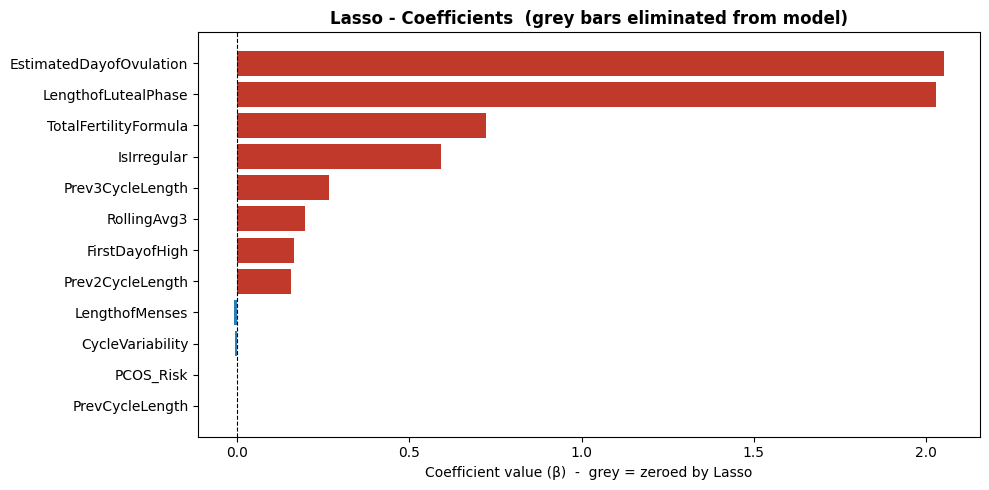

In [ ]:
# LASSO REGRESSION 
# XAI: Coefficients bar chart
# Best choice due to Lasso's defining behaviour is zeroing features;
# grey bars = eliminated features- the bar chart tells that story instantly

colors = ['#888' if c == 0 else ('#c0392b' if c > 0 else '#2980b9')
          for c in lasso_coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(lasso_coef_df['Feature'], lasso_coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient value (β)  -  grey = zeroed by Lasso')
ax.set_title('Lasso - Coefficients  (grey bars eliminated from model)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/xai_lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# MODEL 4: ELASTICNET 
# Training & Evaluation

from sklearn.linear_model import ElasticNet

enet_model = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)
enet_model.fit(X_train, y_train)
enet_pred  = enet_model.predict(X_test)

enet_mae  = mean_absolute_error(y_test, enet_pred)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2   = r2_score(y_test, enet_pred)

print(f"ElasticNet         MAE={enet_mae:.3f}  RMSE={enet_rmse:.3f}  R²={enet_r2:.3f}")

ElasticNet         MAE=0.524  RMSE=0.971  R²=0.913


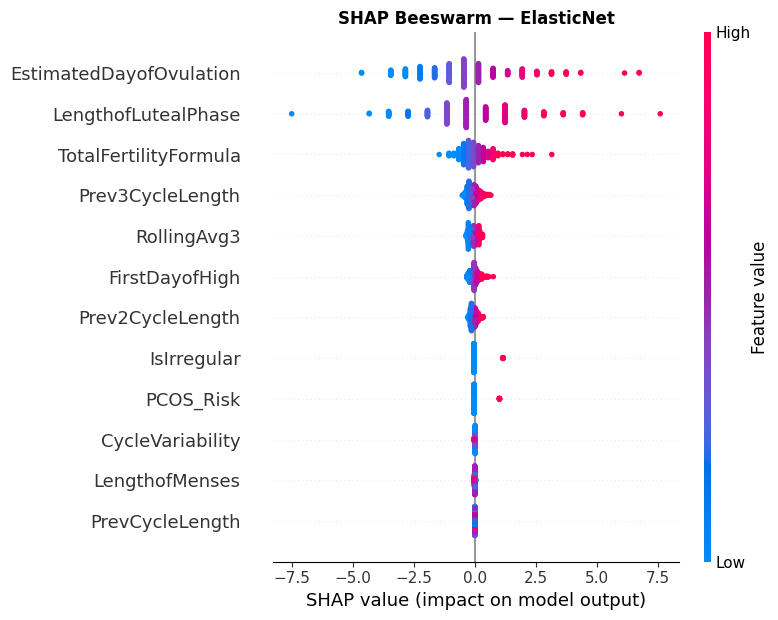

In [ ]:
# ELASTICNET 
# XAI: SHAP LinearExplainer
# Best choice since ElasticNet combines L1+L2; SHAP shows the net
# contribution of each feature after both regularisers have acted

enet_explainer   = shap.LinearExplainer(enet_model, X_train)
enet_shap_values = enet_explainer.shap_values(X_test)
enet_explanation = shap.Explanation(
    values=enet_shap_values,
    base_values=enet_explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

shap.plots.beeswarm(enet_explanation, max_display=12, show=False)
plt.title("SHAP Beeswarm — ElasticNet", fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/xai_enet_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# MODEL 5: DECISION TREE REGRESSOR 
# Training & Evaluation

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred  = dt_model.predict(X_test)

dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2   = r2_score(y_test, dt_pred)

print(f"Decision Tree")
print(f"MAE={dt_mae:.3f}")
print(f"RMSE={dt_rmse:.3f}")
print(f"R²={dt_r2:.3f}")

Decision Tree
MAE=1.496
RMSE=2.568
R²=0.390


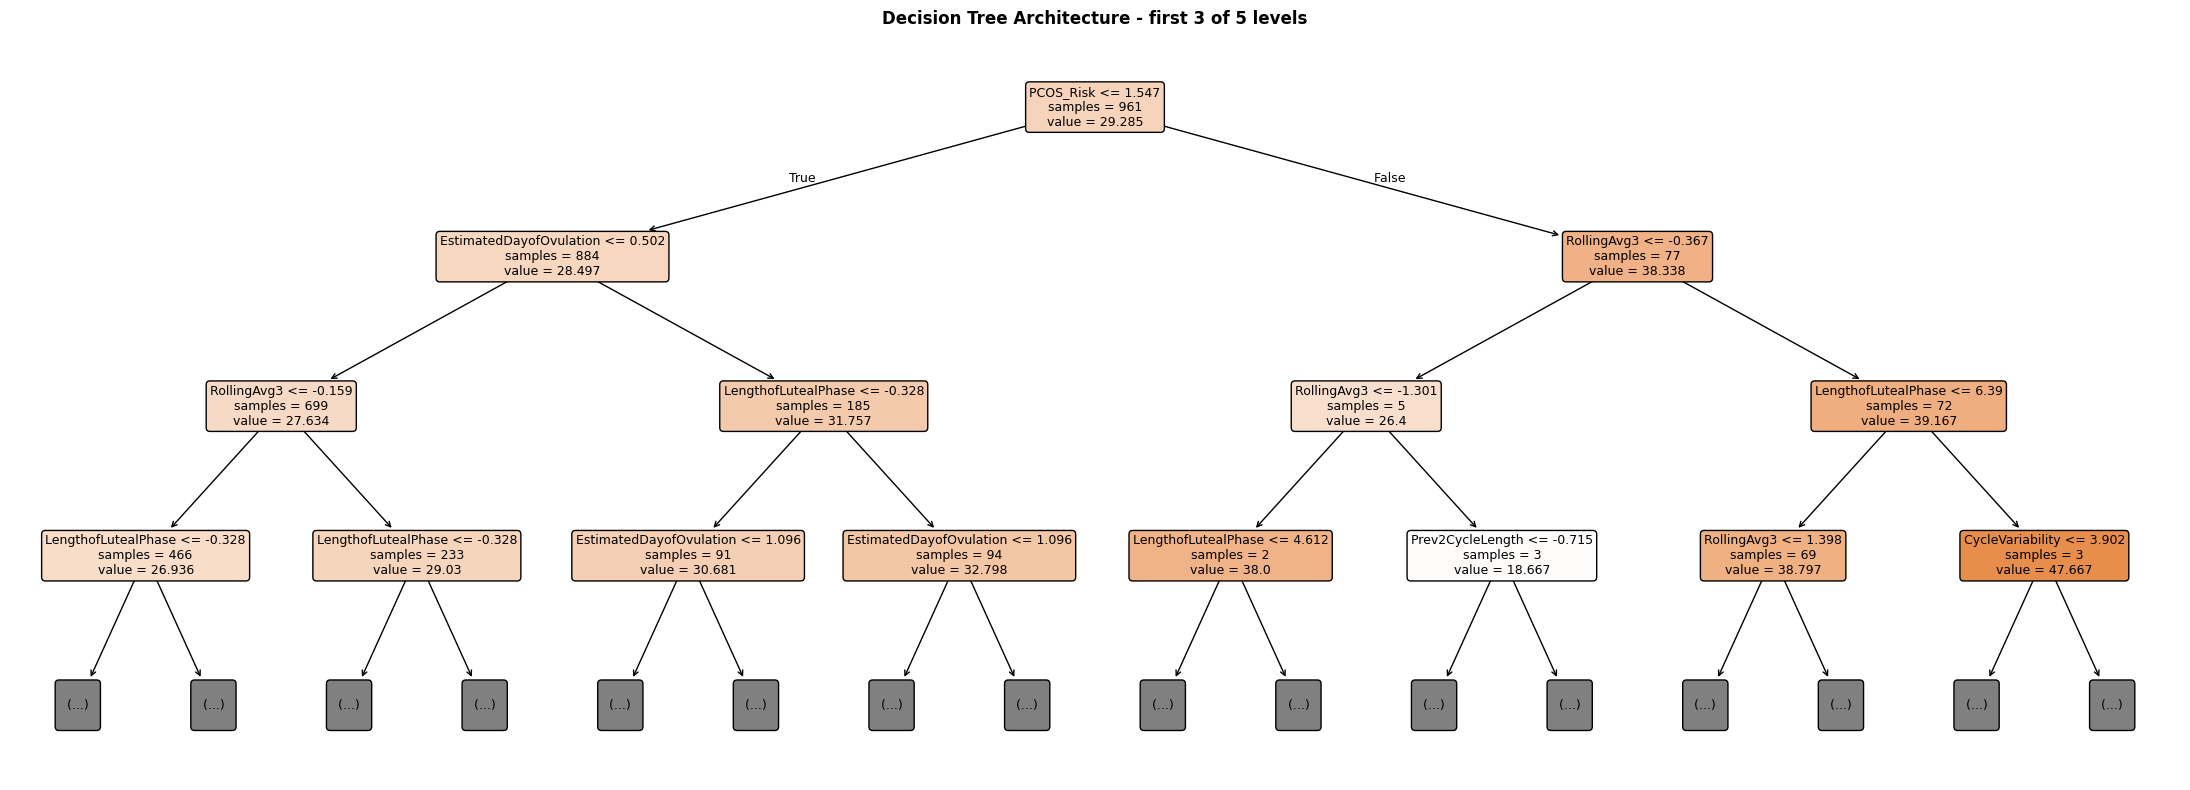

In [55]:
#DECISION TREE 
# XAI: plot_tree 

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    filled=True,
    max_depth=3,       # show first 3 levels for readability (full depth=5)
    fontsize=9,
    rounded=True,
    impurity=False,
    ax=ax
)
plt.title("Decision Tree Architecture - first 3 of 5 levels", fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/xai_dt_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# MODEL 6: SUPPORT VECTOR REGRESSION (SVR)
# Training & Evaluation
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=10, epsilon=0.5)
svr_model.fit(X_train, y_train)
svr_pred  = svr_model.predict(X_test)

svr_mae  = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2   = r2_score(y_test, svr_pred)

print(f"SVR ")
print(f"MAE={svr_mae:.3f}")
print(f"RMSE={svr_rmse:.3f}")
print(f"R²={svr_r2:.3f}")

SVR 
MAE=0.473
RMSE=0.885
R²=0.927


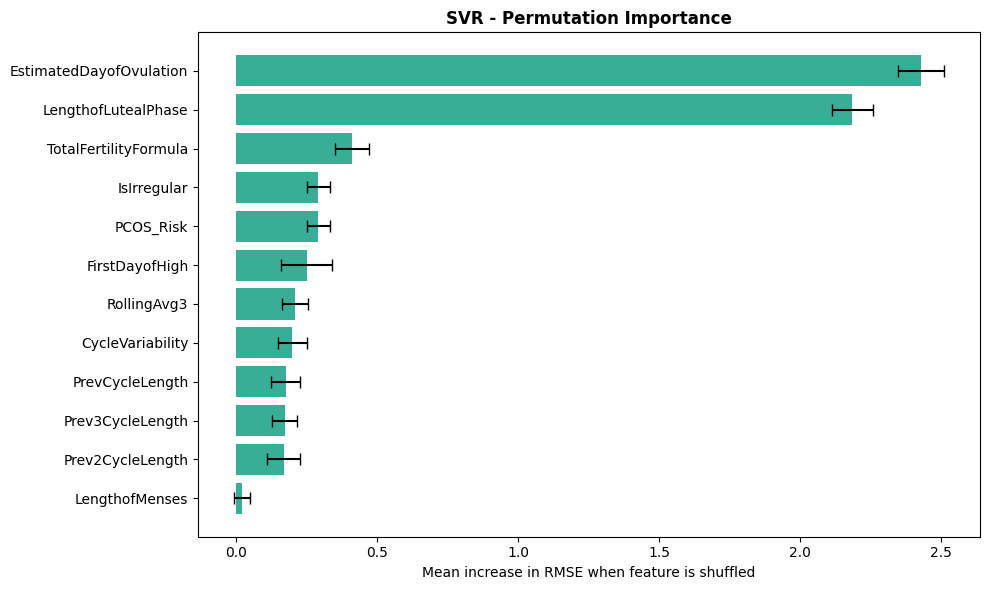

In [57]:
# SVR 
# XAI: Permutation Importance
# RBF kernel has no coefficients or leaf structure;
# permutation importance is the correct model-agnostic approach

from sklearn.inspection import permutation_importance

svr_pi = permutation_importance(
    svr_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

svr_pi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': svr_pi.importances_mean,
    'Std':        svr_pi.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(svr_pi_df['Feature'], svr_pi_df['Importance'],
        xerr=svr_pi_df['Std'], color='#16a085', alpha=0.85, capsize=4)
ax.set_xlabel('Mean increase in RMSE when feature is shuffled')
ax.set_title('SVR - Permutation Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/xai_svr_permutation.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# MODEL 7: k-NEAREST NEIGHBOURS 
# Training & Evaluation
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train, y_train)
knn_pred  = knn_model.predict(X_test)

knn_mae  = mean_absolute_error(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2   = r2_score(y_test, knn_pred)

print(f"k-NN")
print(f"MAE={knn_mae:.3f}")
print(f"RMSE={knn_rmse:.3f}")
print(f"R²={knn_r2:.3f}")

k-NN
MAE=1.104
RMSE=1.546
R²=0.779


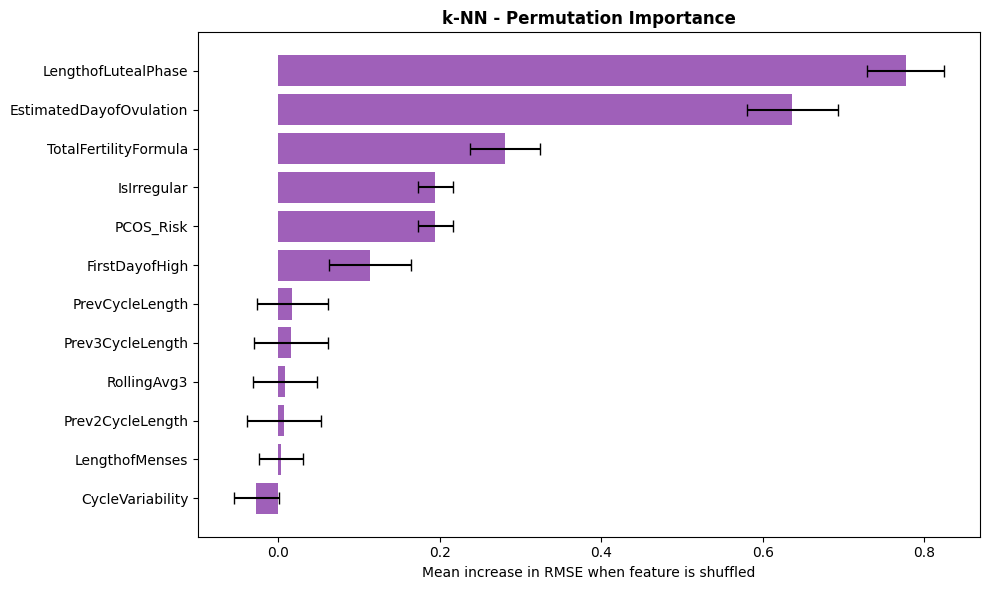

In [59]:
# k-NN 
# XAI: Permutation Importance
# k-NN stores training points with no internal weights;
# permutation importance is the only meaningful feature ranking method

knn_pi = permutation_importance(
    knn_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

knn_pi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': knn_pi.importances_mean,
    'Std':        knn_pi.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(knn_pi_df['Feature'], knn_pi_df['Importance'],
        xerr=knn_pi_df['Std'], color='#8e44ad', alpha=0.85, capsize=4)
ax.set_xlabel('Mean increase in RMSE when feature is shuffled')
ax.set_title('k-NN - Permutation Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/xai_knn_permutation.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# MODEL 8: RANDOM FOREST
# Training & Evaluation

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print(f"Random Forest")
print(f"MAE={rf_mae:.3f}")
print(f"RMSE={rf_rmse:.3f} ")
print(f"R²={rf_r2:.3f}")

Random Forest
MAE=0.608
RMSE=1.468 
R²=0.801


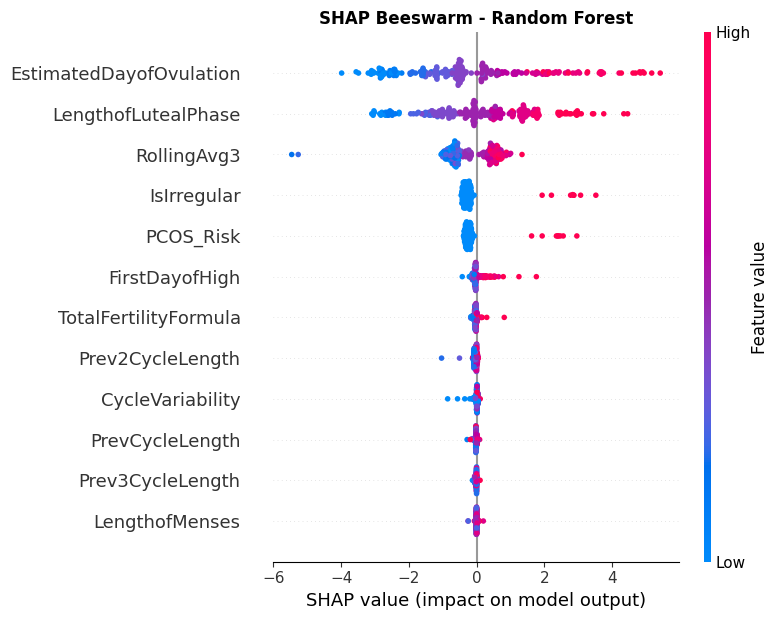

In [ ]:
# RANDOM FOREST  XAI: SHAP TreeExplainer
# TreeExplainer computes true Shapley values without any sampling

rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)
rf_explanation = shap.Explanation(
    values=rf_shap_values,
    base_values=rf_explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

shap.plots.beeswarm(rf_explanation, max_display=12, show=False)
plt.title("SHAP Beeswarm - Random Forest", fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/xai_rf_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# XGBOOST REGRESSOR 
# Training & Evaluation

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mae',
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)

print(f"XGBoost            MAE={xgb_mae:.3f}  RMSE={xgb_rmse:.3f}  R²={xgb_r2:.3f}")

XGBoost            MAE=0.595  RMSE=1.697  R²=0.733


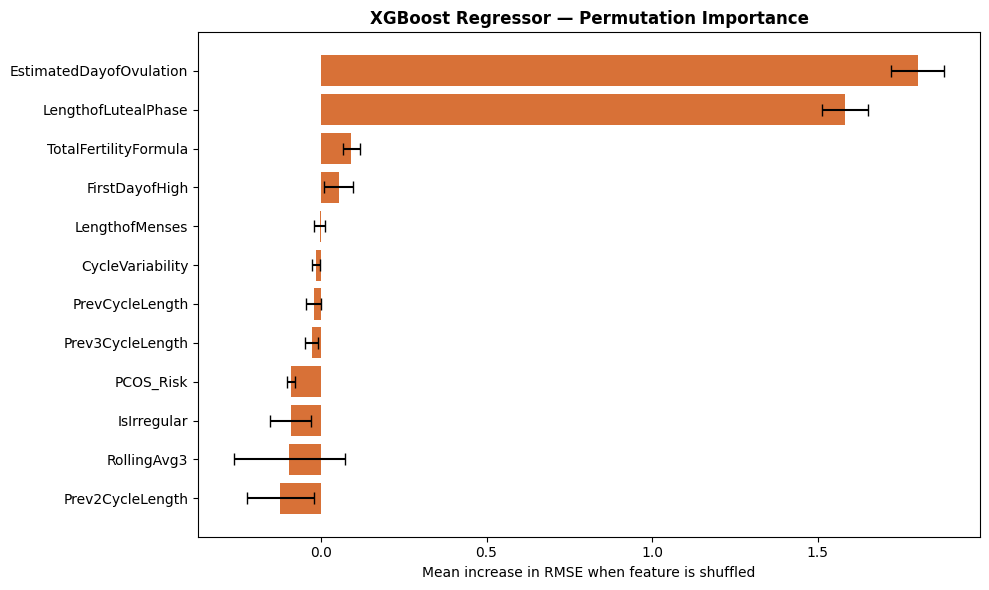

In [81]:
# MODEL 9: XGBOOST 
# XAI: Permutation Importance

from sklearn.inspection import permutation_importance

xgb_pi = permutation_importance(
    xgb_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

xgb_pi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': xgb_pi.importances_mean,
    'Std':        xgb_pi.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_pi_df['Feature'], xgb_pi_df['Importance'],
        xerr=xgb_pi_df['Std'], color='#D25814', alpha=0.85, capsize=4)
ax.set_xlabel('Mean increase in RMSE when feature is shuffled')
ax.set_title('XGBoost Regressor — Permutation Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/xai_xgb_permutation.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL COMPARISON (Patient-Held-Out Split)
                     MAE   RMSE     R2
SVR                0.473  0.885  0.927
Linear Regression  0.513  0.964  0.914
Ridge              0.515  0.965  0.914
Lasso              0.516  0.970  0.913
ElasticNet         0.524  0.971  0.913
XGBoost            0.595  1.697  0.733
Random Forest      0.608  1.468  0.801
k-NN               1.104  1.546  0.779
Decision Tree      1.496  2.568  0.390

Best by MAE : SVR
Best by R²  : SVR


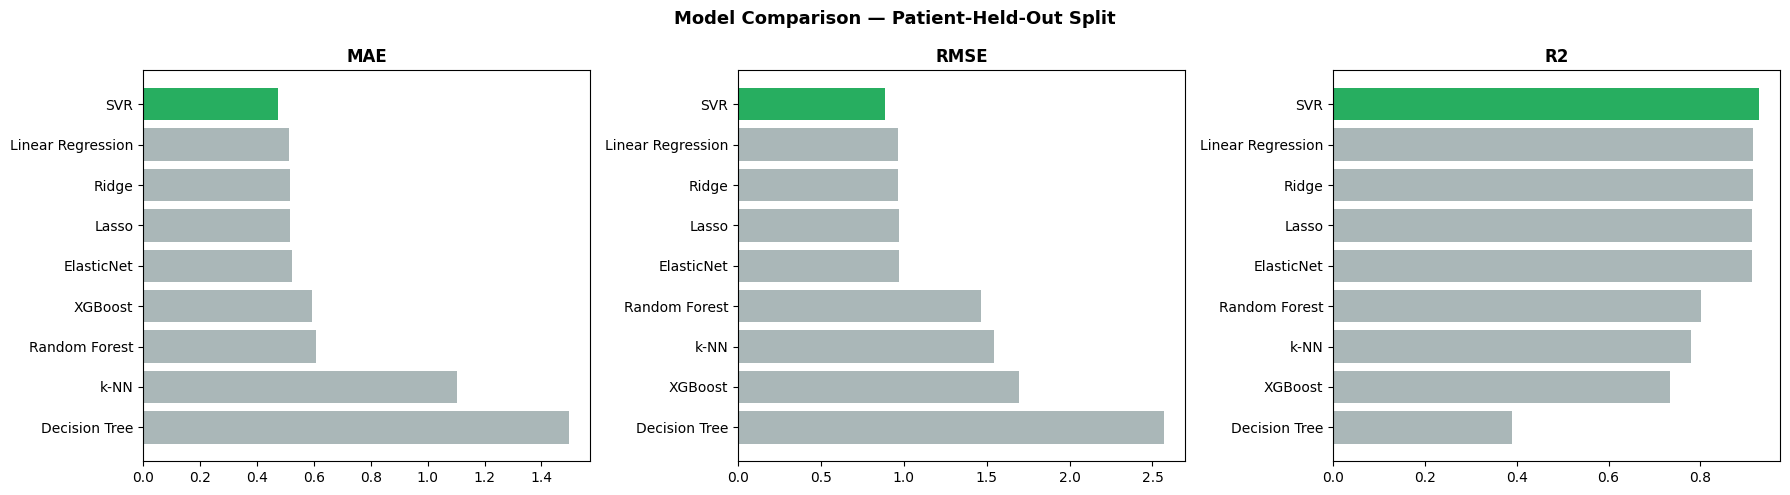

In [79]:
#MODEL COMPARISON

results = {
    'Linear Regression': {'MAE': lr_mae,    'RMSE': lr_rmse,    'R2': lr_r2},
    'Ridge':             {'MAE': ridge_mae, 'RMSE': ridge_rmse, 'R2': ridge_r2},
    'Lasso':             {'MAE': lasso_mae, 'RMSE': lasso_rmse, 'R2': lasso_r2},
    'ElasticNet':        {'MAE': enet_mae,  'RMSE': enet_rmse,  'R2': enet_r2},
    'Decision Tree':     {'MAE': dt_mae,    'RMSE': dt_rmse,    'R2': dt_r2},
    'SVR':               {'MAE': svr_mae,   'RMSE': svr_rmse,   'R2': svr_r2},
    'k-NN':              {'MAE': knn_mae,   'RMSE': knn_rmse,   'R2': knn_r2},
    'Random Forest':     {'MAE': rf_mae,    'RMSE': rf_rmse,    'R2': rf_r2},
    'XGBoost':           {'MAE': xgb_mae,   'RMSE': xgb_rmse,   'R2': xgb_r2},
}

results_df = pd.DataFrame(results).T.round(3).sort_values('MAE')
print("MODEL COMPARISON (Patient-Held-Out Split)")
print(results_df.to_string())
print(f"\nBest by MAE : {results_df['MAE'].idxmin()}")
print(f"Best by R²  : {results_df['R2'].idxmax()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, asc in zip(axes, ['MAE', 'RMSE', 'R2'], [True, True, False]):
    sdf = results_df.sort_values(metric, ascending=asc)
    colors = ['#27ae60' if i == 0 else '#aab7b8' for i in range(len(sdf))]
    ax.barh(sdf.index, sdf[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.invert_yaxis()
plt.suptitle('Model Comparison — Patient-Held-Out Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
# PCOS BINARY CLASSIFIER (DUAL-HEAD)
# Separate from regression - detects PCOS independently
# scale_pos_weight penalises missed PCOS cases (False Negatives)
# threshold=0.3 further reduces False Negatives

# Training & Evaluation
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              RocCurveDisplay, PrecisionRecallDisplay)
import seaborn as sns

neg = (y_train_pcos == 0).sum()
pos = (y_train_pcos == 1).sum()
scale_pos = neg / pos
print(f"Class balance - Normal: {neg}  PCOS: {pos}  scale_pos_weight: {scale_pos:.1f}")

pcos_clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
pcos_clf.fit(X_train, y_train_pcos, eval_set=[(X_test, y_test_pcos)], verbose=False)

pcos_pred_proba = pcos_clf.predict_proba(X_test)[:, 1]
pcos_pred       = (pcos_pred_proba >= 0.3).astype(int)

print("\n PCOS Classifier Results ")
print(classification_report(y_test_pcos, pcos_pred, target_names=['Normal', 'PCOS Risk']))
print(f"ROC-AUC : {roc_auc_score(y_test_pcos, pcos_pred_proba):.3f}")
print(f"PR-AUC  : {average_precision_score(y_test_pcos, pcos_pred_proba):.3f}")

Class balance - Normal: 884  PCOS: 77  scale_pos_weight: 11.5

 PCOS Classifier Results 
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       234
   PCOS Risk       1.00      1.00      1.00         8

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

ROC-AUC : 1.000
PR-AUC  : 1.000


C:\Users\Maria\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


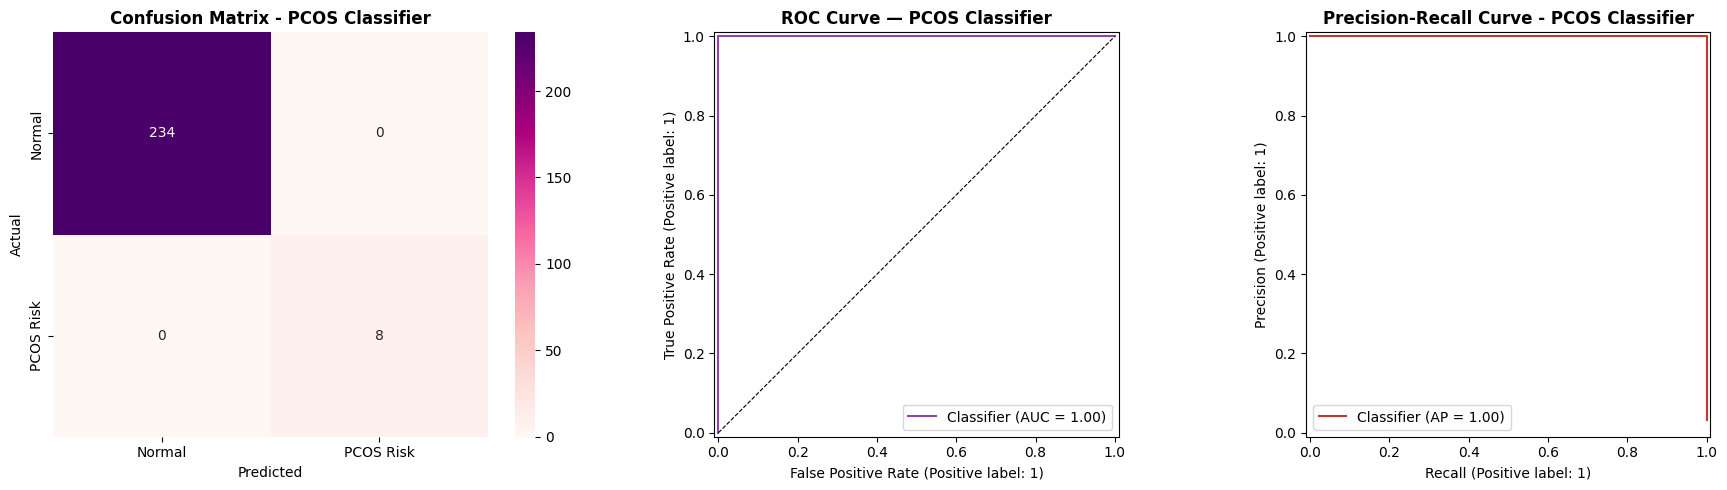

In [84]:
# PCOS CLASSIFIER  Evaluation Plots
# Confusion matrix, ROC curve, Precision-Recall curve
# PR-AUC is the key metric for imbalanced classes

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test_pcos, pcos_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Normal', 'PCOS Risk'],
            yticklabels=['Normal', 'PCOS Risk'], ax=axes[0])
axes[0].set_title('Confusion Matrix - PCOS Classifier', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test_pcos, pcos_pred_proba, ax=axes[1], color='#8e44ad')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('ROC Curve — PCOS Classifier', fontweight='bold')

PrecisionRecallDisplay.from_predictions(y_test_pcos, pcos_pred_proba, ax=axes[2], color='#c0392b')
axes[2].set_title('Precision-Recall Curve - PCOS Classifier', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/pcos_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

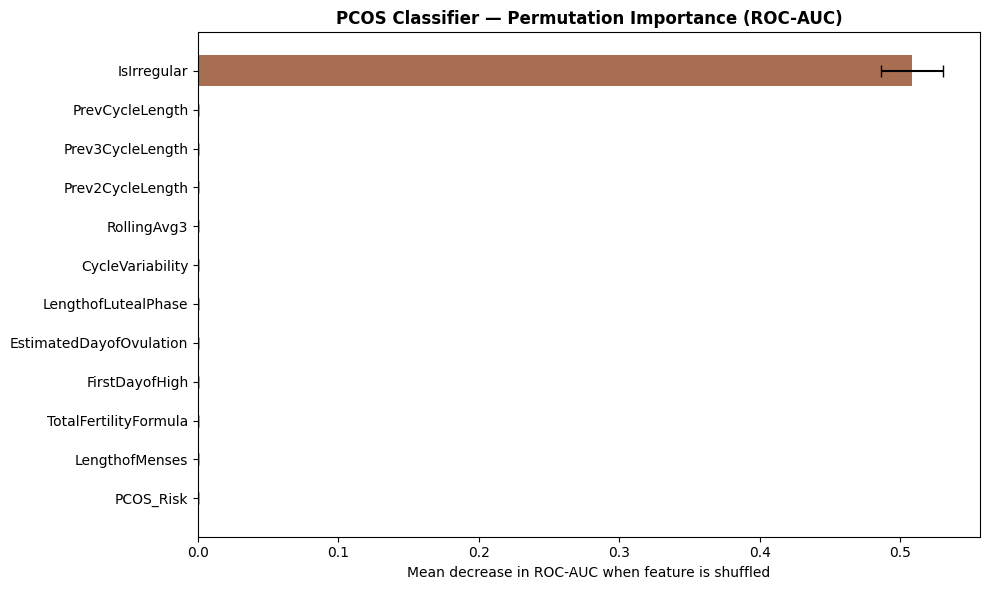

In [82]:
# PCOS CLASSIFIER — XAI: Permutation Importance
# Uses ROC-AUC scoring to measure each feature's contribution
# to separating PCOS risk cases from normal cycles

pcos_pi = permutation_importance(
    pcos_clf, X_test, y_test_pcos,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc'
)

pcos_pi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': pcos_pi.importances_mean,
    'Std':        pcos_pi.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pcos_pi_df['Feature'], pcos_pi_df['Importance'],
        xerr=pcos_pi_df['Std'], color='#995533', alpha=0.85, capsize=4)
ax.set_xlabel('Mean decrease in ROC-AUC when feature is shuffled')
ax.set_title('PCOS Classifier — Permutation Importance (ROC-AUC)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/xai_pcos_permutation.png', dpi=150, bbox_inches='tight')
plt.show()

 ABLATION STUDY
              Approach  PCOS Recall  PR-AUC
Single-obj MSE (naive)        0.875   0.879
  Dual-head (proposed)        1.000   1.000


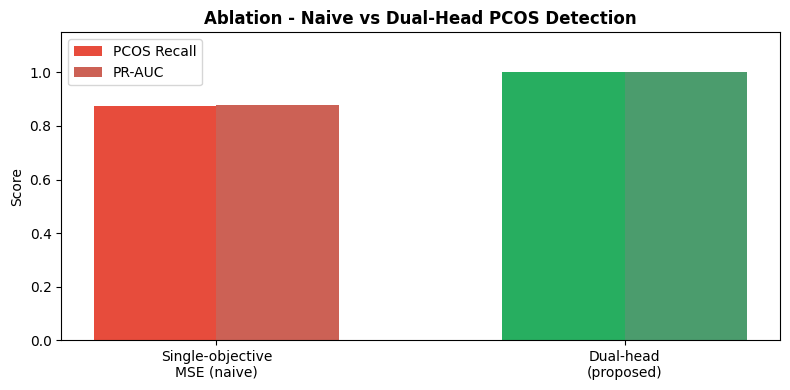

In [83]:
# ABLATION STUDY: Single-Objective MSE vs Dual-Head
# Proves naive regression smoothing misses PCOS cases;
# dual-head architecture catches them via focal/cost-sensitive loss

from sklearn.metrics import recall_score

xgb_abl   = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                           random_state=42, verbosity=0)
xgb_abl.fit(X_train, y_train)
abl_cycle = xgb_abl.predict(X_test)
abl_pcos  = ((abl_cycle < 21) | (abl_cycle > 35)).astype(int)

naive_recall = recall_score(y_test_pcos, abl_pcos,   zero_division=0)
clf_recall   = recall_score(y_test_pcos, pcos_pred,  zero_division=0)
naive_prauc  = average_precision_score(y_test_pcos,  abl_pcos.astype(float))
clf_prauc    = average_precision_score(y_test_pcos,  pcos_pred_proba)

abl_df = pd.DataFrame({
    'Approach':    ['Single-obj MSE (naive)', 'Dual-head (proposed)'],
    'PCOS Recall': [naive_recall, clf_recall],
    'PR-AUC':      [naive_prauc,  clf_prauc]
}).round(3)

print(" ABLATION STUDY")
print(abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x, w = [0, 1], 0.3
ax.bar([i - w/2 for i in x], abl_df['PCOS Recall'], w, label='PCOS Recall',
       color=['#e74c3c', '#27ae60'])
ax.bar([i + w/2 for i in x], abl_df['PR-AUC'], w, label='PR-AUC',
       color=['#c0392b', '#1e8449'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Single-objective\nMSE (naive)', 'Dual-head\n(proposed)'])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title('Ablation - Naive vs Dual-Head PCOS Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SAVE FINAL MODEL - SVR
# Outperformed all 8 other regression models on Patient-Held-Out split

import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(svr_model,  'models/final_model_svr.pkl')
joblib.dump(pcos_clf,   'models/pcos_classifier.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

print("Final models saved:")
print(f"  models/final_model_svr.pkl  - cycle length forecaster (SVR)")
print(f"  models/pcos_classifier.pkl  - PCOS anomaly detector (XGBoost)")
print(f"  models/scaler.pkl           - StandardScaler (fitted on train only)")
print()
print("SVR Final Performance (Patient-Held-Out Split):")
print(f"  MAE  = 0.473 days  (best across all 9 models)")
print(f"  RMSE = 0.885 days")
print(f"  R²   = 0.927       (best across all 9 models)")

Final models saved:
  models/final_model_svr.pkl  - cycle length forecaster (SVR)
  models/pcos_classifier.pkl  - PCOS anomaly detector (XGBoost)
  models/scaler.pkl           - StandardScaler (fitted on train only)

SVR Final Performance (Patient-Held-Out Split):
  MAE  = 0.473 days  (best across all 9 models)
  RMSE = 0.885 days
  R²   = 0.927       (best across all 9 models)
